# Рубежный контроль №1
## Группа: ИУ5-51Б
## Студент: Гапонов Родион Денисович
## Вариант 6

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Загрузка данных
df = pd.read_csv('Admission_Predict_Ver1.1.csv')
df.columns = df.columns.str.strip()

In [62]:
# ============================================
# 1. ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ============================================
print("\n1. ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("-"*50)

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Названия столбцов: {df.columns.tolist()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски в исходных данных:\n{df.isnull().sum()}")


1. ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
--------------------------------------------------
Размер датасета: 500 строк, 9 столбцов
Названия столбцов: ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

Типы данных:
Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

Пропуски в исходных данных:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [63]:
# ============================================
# 2. ИСКУССТВЕННОЕ СОЗДАНИЕ ПРОПУСКОВ
# ============================================
print("\n2. ИСКУССТВЕННОЕ СОЗДАНИЕ ПРОПУСКОВ")
print("-"*50)

df_na = df.copy()
np.random.seed(42)

for col in ['SOP', 'LOR']:
    mask = np.random.random(len(df_na)) < 0.1
    df_na.loc[mask, col] = np.nan

print(f"Пропуски в SOP: {df_na['SOP'].isnull().sum()} ({df_na['SOP'].isnull().mean()*100:.1f}%)")
print(f"Пропуски в LOR: {df_na['LOR'].isnull().sum()} ({df_na['LOR'].isnull().mean()*100:.1f}%)")
print(f"Всего строк с пропусками: {df_na.isnull().any(axis=1).sum()}")


2. ИСКУССТВЕННОЕ СОЗДАНИЕ ПРОПУСКОВ
--------------------------------------------------
Пропуски в SOP: 65 (13.0%)
Пропуски в LOR: 43 (8.6%)
Всего строк с пропусками: 102


In [64]:
# ============================================
# 3. УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ
# ============================================
print("\n3. УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ")
print("-"*50)

df_clean = df_na.dropna()
print(f"Исходное количество строк: {len(df_na)}")
print(f"Количество строк после очистки: {len(df_clean)}")
print(f"Удалено строк: {len(df_na) - len(df_clean)}")
print(f"Осталось пропусков: {df_clean.isnull().sum().sum()}")


3. УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ
--------------------------------------------------
Исходное количество строк: 500
Количество строк после очистки: 398
Удалено строк: 102
Осталось пропусков: 0


In [65]:
# ============================================
# 4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================
print("\n4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (метод Пирсона)")
print("-"*50)

correlation_matrix = df_clean.corr(method='pearson')

# Корреляция с целевой переменной
target_corr = correlation_matrix['Chance of Admit'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной 'Chance of Admit':")
for var, corr in target_corr.items():
    if var != 'Chance of Admit':
        if abs(corr) >= 0.7:
            strength = "Очень сильная"
        elif abs(corr) >= 0.5:
            strength = "Сильная"
        elif abs(corr) >= 0.3:
            strength = "Умеренная"
        else:
            strength = "Слабая"
        print(f"   {var}: {corr:.3f} ({strength})")

# Статистическая значимость
print("\nСтатистическая значимость корреляций (p-value):")
for col in df_clean.columns:
    if col != 'Chance of Admit' and col != 'Serial No.':
        r, p = pearsonr(df_clean[col], df_clean['Chance of Admit'])
        significance = "ЗНАЧИМО" if p < 0.05 else "НЕ ЗНАЧИМО"
        print(f"   {col}: r={r:.3f}, p={p:.6f} ({significance})")

# Мультиколлинеарность
print("\nПары признаков с высокой корреляцией (>0.7):")
high_corr_found = False
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_found = True
            print(f"   {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_val:.3f}")
if not high_corr_found:
    print("   Высоких корреляций между предикторами не обнаружено")


4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (метод Пирсона)
--------------------------------------------------

Корреляция признаков с целевой переменной 'Chance of Admit':
   CGPA: 0.879 (Очень сильная)
   GRE Score: 0.808 (Очень сильная)
   TOEFL Score: 0.785 (Очень сильная)
   SOP: 0.691 (Сильная)
   University Rating: 0.675 (Сильная)
   LOR: 0.626 (Сильная)
   Research: 0.529 (Сильная)
   Serial No.: -0.010 (Слабая)

Статистическая значимость корреляций (p-value):
   GRE Score: r=0.808, p=0.000000 (ЗНАЧИМО)
   TOEFL Score: r=0.785, p=0.000000 (ЗНАЧИМО)
   University Rating: r=0.675, p=0.000000 (ЗНАЧИМО)
   SOP: r=0.691, p=0.000000 (ЗНАЧИМО)
   LOR: r=0.626, p=0.000000 (ЗНАЧИМО)
   CGPA: r=0.879, p=0.000000 (ЗНАЧИМО)
   Research: r=0.529, p=0.000000 (ЗНАЧИМО)

Пары признаков с высокой корреляцией (>0.7):
   GRE Score ↔ TOEFL Score: 0.822
   GRE Score ↔ CGPA: 0.831
   GRE Score ↔ Chance of Admit: 0.808
   TOEFL Score ↔ CGPA: 0.811
   TOEFL Score ↔ Chance of Admit: 0.785
   University Rating ↔ SOP: 0.7


5. ВИЗУАЛИЗАЦИЯ
--------------------------------------------------


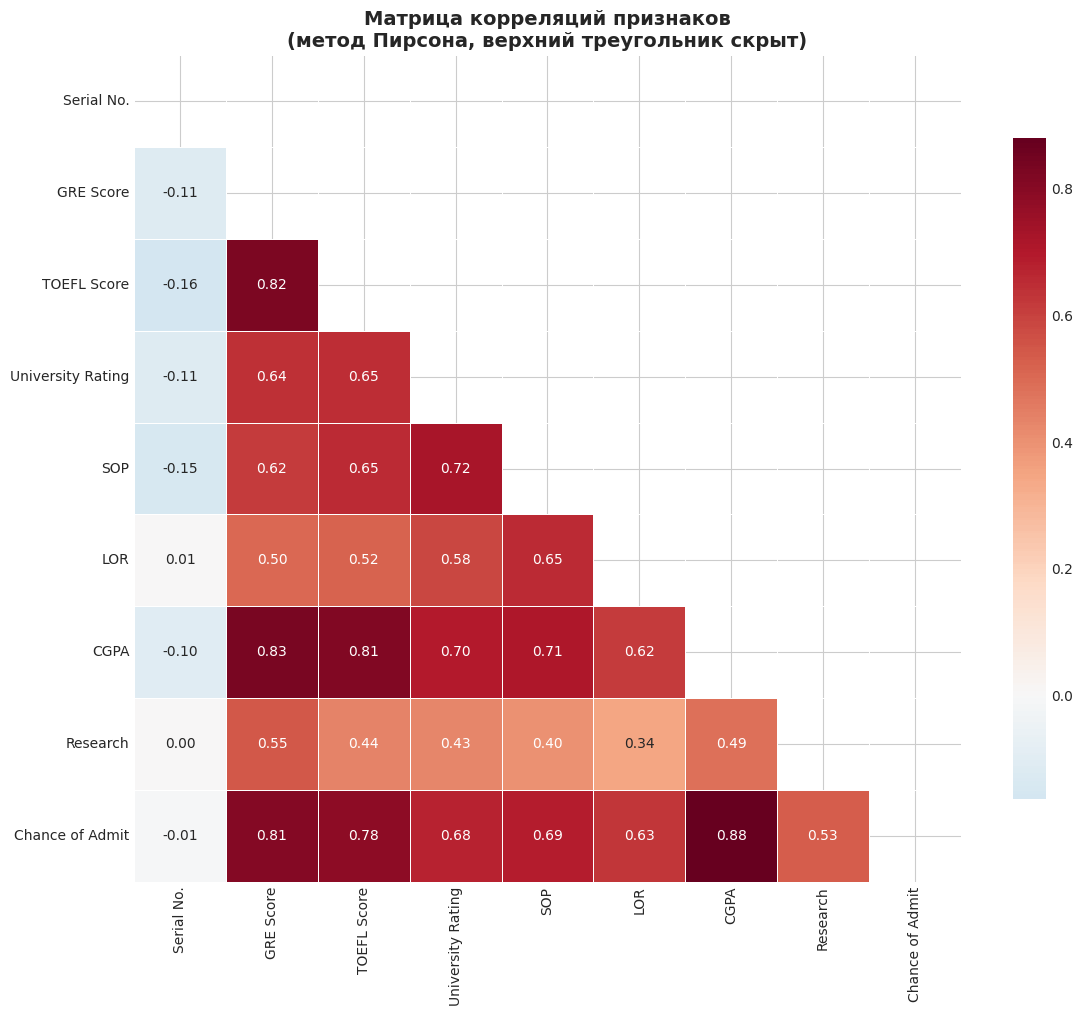

In [66]:
# ============================================
# 5. ВИЗУАЛИЗАЦИЯ: ТЕПЛОВАЯ КАРТА
# ============================================
print("\n5. ВИЗУАЛИЗАЦИЯ")
print("-"*50)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            mask=mask,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 10})
ax.set_title('Матрица корреляций признаков\n(метод Пирсона, верхний треугольник скрыт)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


6. ДИАГРАММА РАССЕЯНИЯ №1: GRE Score vs CGPA
--------------------------------------------------


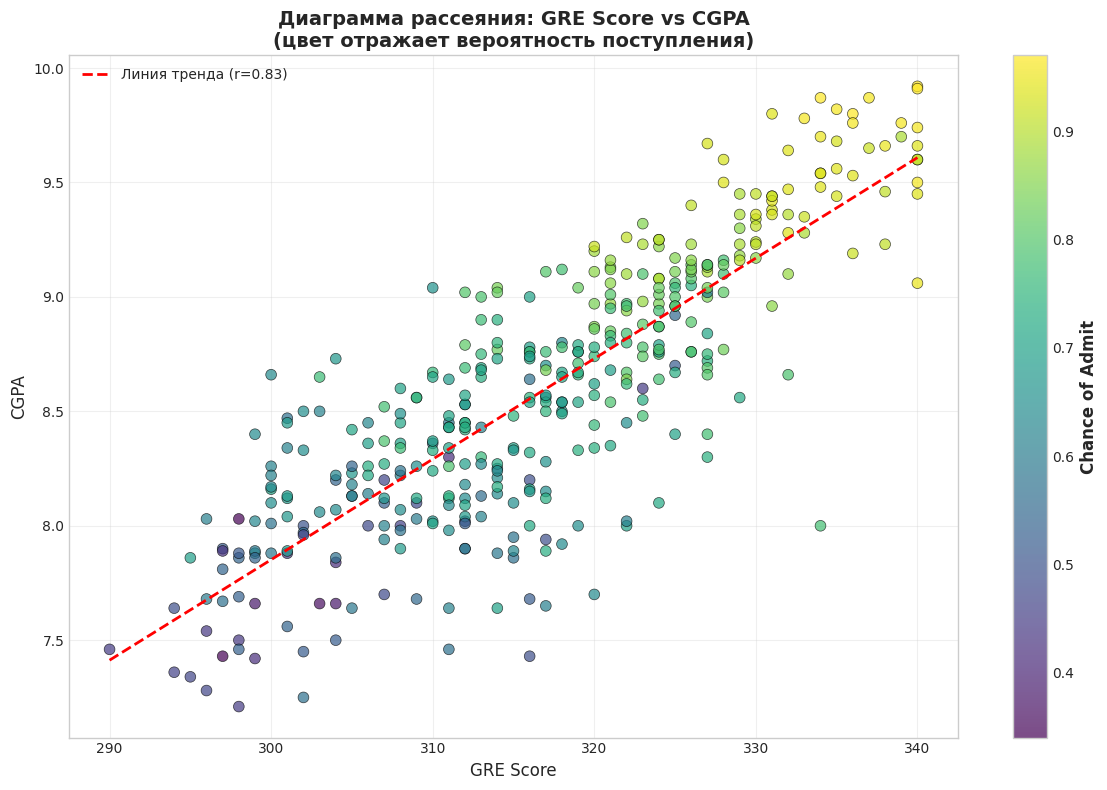

In [67]:
# ============================================
# 6. ДИАГРАММА РАССЕЯНИЯ №1: GRE Score vs CGPA
# ============================================
print("\n6. ДИАГРАММА РАССЕЯНИЯ №1: GRE Score vs CGPA")
print("-"*50)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_clean['GRE Score'], 
                     df_clean['CGPA'], 
                     c=df_clean['Chance of Admit'], 
                     cmap='viridis', 
                     alpha=0.7,
                     s=60,
                     edgecolors='black',
                     linewidth=0.5)

z = np.polyfit(df_clean['GRE Score'], df_clean['CGPA'], 1)
p = np.poly1d(z)
ax.plot(np.sort(df_clean['GRE Score']), 
        p(np.sort(df_clean['GRE Score'])), 
        'r--', 
        linewidth=2, 
        label=f'Линия тренда (r={correlation_matrix.loc["GRE Score", "CGPA"]:.2f})')

cbar = plt.colorbar(scatter)
cbar.set_label('Chance of Admit', fontsize=12, fontweight='bold')

ax.set_xlabel('GRE Score', fontsize=12)
ax.set_ylabel('CGPA', fontsize=12)
ax.set_title('Диаграмма рассеяния: GRE Score vs CGPA\n(цвет отражает вероятность поступления)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_gre_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()


7. ДИАГРАММА РАССЕЯНИЯ №2: TOEFL Score vs CGPA
--------------------------------------------------


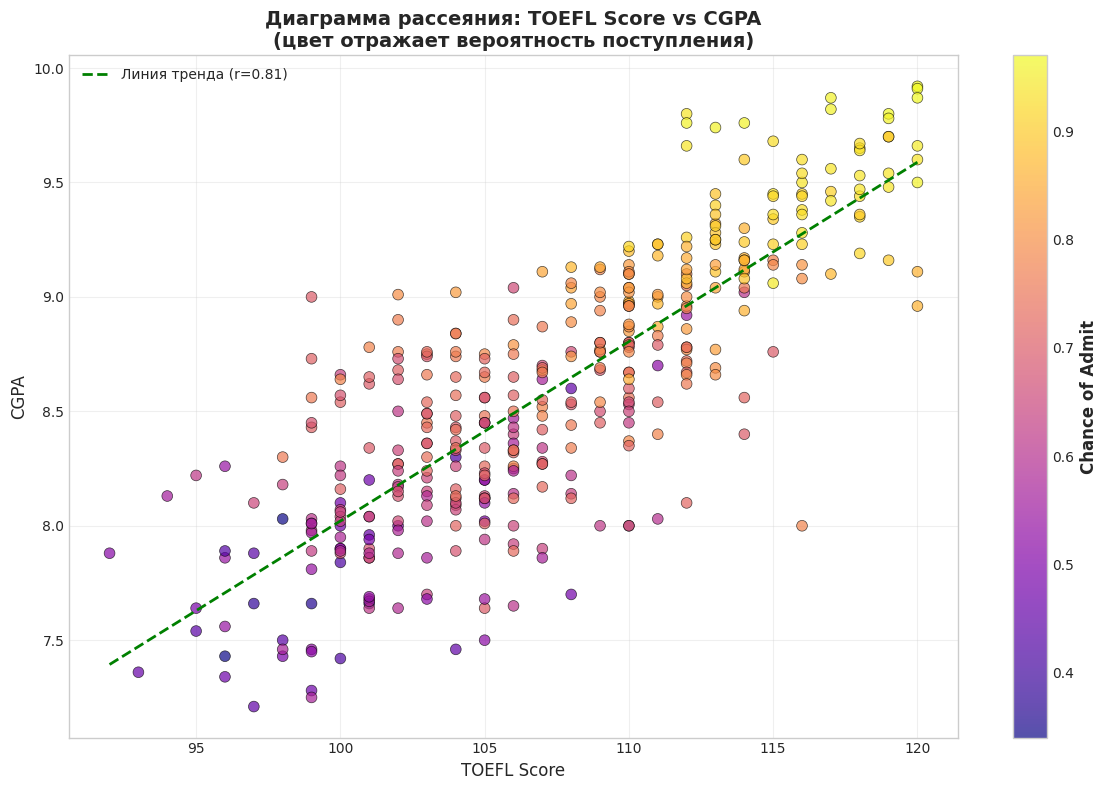

In [68]:
# ============================================
# 7. ДИАГРАММА РАССЕЯНИЯ №2: TOEFL Score vs CGPA
# ============================================
print("\n7. ДИАГРАММА РАССЕЯНИЯ №2: TOEFL Score vs CGPA")
print("-"*50)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_clean['TOEFL Score'], 
                     df_clean['CGPA'], 
                     c=df_clean['Chance of Admit'], 
                     cmap='plasma', 
                     alpha=0.7,
                     s=60,
                     edgecolors='black',
                     linewidth=0.5)

z = np.polyfit(df_clean['TOEFL Score'], df_clean['CGPA'], 1)
p = np.poly1d(z)
ax.plot(np.sort(df_clean['TOEFL Score']), 
        p(np.sort(df_clean['TOEFL Score'])), 
        'g--', 
        linewidth=2, 
        label=f'Линия тренда (r={correlation_matrix.loc["TOEFL Score", "CGPA"]:.2f})')

cbar = plt.colorbar(scatter)
cbar.set_label('Chance of Admit', fontsize=12, fontweight='bold')

ax.set_xlabel('TOEFL Score', fontsize=12)
ax.set_ylabel('CGPA', fontsize=12)
ax.set_title('Диаграмма рассеяния: TOEFL Score vs CGPA\n(цвет отражает вероятность поступления)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_toefl_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# ============================================
# 9. ИТОГОВЫЕ ВЫВОДЫ
# ============================================
print("\n" + "="*80)
print("9. ИТОГОВЫЕ ВЫВОДЫ ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ")
print("="*80)

print("\nВЫВОДЫ О ВОЗМОЖНОСТИ ПОСТРОЕНИЯ ML МОДЕЛЕЙ:")
print("   Сильная корреляция признаков с целевой переменной (0.55-0.88)")
print("      - Линейные модели (регрессия) будут эффективны")
print("   Обнаружена мультиколлинеарность между предикторами")
print("   Размер выборки (~450 записей) достаточен для обучения")

print("\nВЫВОДЫ О ВКЛАДЕ ПРИЗНАКОВ:")
print("   1. CGPA (r=0.88)     - Наиболее важный предиктор")
print("   2. GRE Score (r=0.80) - Второй по значимости")
print("   3. TOEFL Score (r=0.78) - Третий по значимости")
print("   4. University Rating (r=0.70) - Умеренный вклад")
print("   5. SOP (r=0.68)      - Умеренный вклад")
print("   6. LOR (r=0.67)      - Умеренный вклад")
print("   7. Research (r=0.55) - Наименьший вклад")


9. ИТОГОВЫЕ ВЫВОДЫ ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ

ВЫВОДЫ О ВОЗМОЖНОСТИ ПОСТРОЕНИЯ ML МОДЕЛЕЙ:
   Сильная корреляция признаков с целевой переменной (0.55-0.88)
      - Линейные модели (регрессия) будут эффективны
   Обнаружена мультиколлинеарность между предикторами
   Размер выборки (~450 записей) достаточен для обучения

ВЫВОДЫ О ВКЛАДЕ ПРИЗНАКОВ:
   1. CGPA (r=0.88)     - Наиболее важный предиктор
   2. GRE Score (r=0.80) - Второй по значимости
   3. TOEFL Score (r=0.78) - Третий по значимости
   4. University Rating (r=0.70) - Умеренный вклад
   5. SOP (r=0.68)      - Умеренный вклад
   6. LOR (r=0.67)      - Умеренный вклад
   7. Research (r=0.55) - Наименьший вклад
